# Exploratory Data Analysis - Karachi AQI Prediction

**Project:** Air Quality Index Prediction for Karachi, Pakistan  
**Objective:** Analyze historical AQI data to understand patterns, correlations, and feature importance  
**Date:** February 2026

## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# MongoDB
from pymongo import MongoClient
import os
from dotenv import load_dotenv

# Statistical analysis
from scipy.stats import pearsonr, spearmanr

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Figure size default
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Load environment variables
load_dotenv()

# MongoDB configuration
MONGO_URI = os.getenv("MONGODB_URI")
DB_NAME = os.getenv("MONGODB_DB")
COLLECTION = os.getenv("MONGODB_COLLECTION")

print(f"MongoDB Database: {DB_NAME}")
print(f"Collection: {COLLECTION}")

MongoDB Database: aqi_feature_store
Collection: aqi_features_v1


In [3]:
# Connect to MongoDB and load data
client = MongoClient(MONGO_URI)
collection = client[DB_NAME][COLLECTION]

# Load all data
print("📊 Loading data from MongoDB...")
cursor = collection.find({})
df = pd.DataFrame(list(cursor))

# Clean data
if '_id' in df.columns:
    df.drop(columns=['_id'], inplace=True)

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"✅ Loaded {len(df):,} records")
print(f"📅 Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"📊 Dataset types: {df['dataset_type'].value_counts().to_dict()}")

📊 Loading data from MongoDB...
✅ Loaded 2,239 records
📅 Date range: 2025-11-17 00:00:00+00:00 to 2026-02-16 15:00:00+00:00
📊 Dataset types: {'historical': 2151, 'online': 88}


## 2. Basic Data Overview

In [4]:
# Dataset shape
print(f"📋 Dataset Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

📋 Dataset Shape: (2239, 23)
   Rows: 2,239
   Columns: 23


In [6]:
# Column information
print("📋 Columns:")
print(df.columns.tolist())
print("\n📋 Data Types:")
df.dtypes

📋 Columns:
['timestamp', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2', 'aqi', 'city', 'temperature', 'humidity', 'wind_speed', 'hour', 'day', 'month', 'day_of_week', 'aqi_lag_1', 'aqi_lag_24', 'aqi_change_1h', 'aqi_change_24h', 'target_aqi', 'dataset_type', 'schema_version']

📋 Data Types:


timestamp         datetime64[ns, UTC]
pm2_5                         float64
pm10                          float64
no2                           float64
o3                            float64
co                            float64
so2                           float64
aqi                             int64
city                           object
temperature                   float64
humidity                        int64
wind_speed                    float64
hour                            int64
day                             int64
month                           int64
day_of_week                     int64
aqi_lag_1                     float64
aqi_lag_24                    float64
aqi_change_1h                 float64
aqi_change_24h                float64
target_aqi                    float64
dataset_type                   object
schema_version                  int64
dtype: object

In [7]:
# First few rows
df.head()

,timestamp,pm2_5,pm10,no2,o3,co,so2,aqi,city,temperature,...,day,month,day_of_week,aqi_lag_1,aqi_lag_24,aqi_change_1h,aqi_change_24h,target_aqi,dataset_type,schema_version
0,2025-11-17 00:00:00+00:00,29.7,30.0,58.6,12.0,382.0,14.1,94,Karachi,18.5,...,17,11,0,93.0,88.0,1.0,6.0,94.0,historical,2
1,2025-11-17 01:00:00+00:00,27.4,27.6,59.7,9.0,795.0,15.6,94,Karachi,18.1,...,17,11,0,94.0,88.0,0.0,6.0,94.0,historical,2
2,2025-11-17 02:00:00+00:00,32.9,33.3,60.7,7.0,1370.0,18.0,94,Karachi,18.0,...,17,11,0,94.0,87.0,0.0,7.0,95.0,historical,2
3,2025-11-17 03:00:00+00:00,42.4,42.6,57.4,17.0,1748.0,22.7,95,Karachi,18.7,...,17,11,0,94.0,86.0,1.0,9.0,95.0,historical,2
4,2025-11-17 04:00:00+00:00,40.0,40.4,46.0,52.0,1756.0,32.1,95,Karachi,21.5,...,17,11,0,95.0,85.0,0.0,10.0,96.0,historical,2


In [8]:
# Statistical summary
df.describe()

,pm2_5,pm10,no2,o3,co,so2,aqi,temperature,humidity,wind_speed,hour,day,month,day_of_week,aqi_lag_1,aqi_lag_24,aqi_change_1h,aqi_change_24h,target_aqi,schema_version
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.0
mean,37.689236,46.999509,33.150201,75.415811,915.841447,22.569406,107.094238,20.974185,51.865118,7.964716,11.441268,15.793658,6.341224,3.002680,107.109424,107.056722,-0.015185,0.037517,107.077713,2.0
std,15.021072,21.225195,25.476423,48.431317,535.820057,10.588626,23.479148,3.946041,20.431026,3.426455,6.913613,8.800760,5.184845,2.001338,23.474210,23.478146,3.052525,24.255610,23.484318,0.0
min,8.100000,8.100000,0.000000,0.000000,91.000000,6.600000,63.000000,9.200000,12.000000,0.200000,0.000000,1.000000,1.000000,0.000000,63.000000,63.000000,-26.000000,-69.000000,63.000000,2.0
25%,26.800000,32.500000,12.000000,32.000000,521.000000,14.800000,89.000000,18.100000,36.000000,5.600000,5.000000,8.000000,1.000000,1.000000,89.000000,89.000000,-1.000000,-14.000000,89.000000,2.0
50%,35.700000,43.000000,26.700000,70.000000,791.000000,19.700000,104.000000,20.800000,50.000000,7.800000,11.000000,16.000000,2.000000,3.000000,104.000000,104.000000,0.000000,-1.000000,104.000000,2.0
75%,45.550000,57.450000,46.800000,115.000000,1175.000000,27.600000,123.000000,23.900000,66.000000,10.100000,17.000000,23.000000,12.000000,5.000000,123.000000,123.000000,1.000000,15.000000,123.000000,2.0
max,95.900000,247.700000,138.500000,195.000000,4515.000000,65.400000,156.000000,29.800000,99.000000,23.800000,23.000000,31.000000,12.000000,6.000000,156.000000,156.000000,29.000000,83.000000,156.000000,2.0


In [9]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("📋 Missing Values:")
missing_df[missing_df['Missing Count'] > 0]

📋 Missing Values:


,Missing Count,Percentage


## 3. AQI Distribution & Categories

In [10]:
# Categorize AQI
def categorize_aqi(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy (Sensitive)"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

df['aqi_category'] = df['aqi'].apply(categorize_aqi)

print("📊 AQI Statistics:")
print(f"   Mean: {df['aqi'].mean():.2f}")
print(f"   Median: {df['aqi'].median():.2f}")
print(f"   Std Dev: {df['aqi'].std():.2f}")
print(f"   Min: {df['aqi'].min():.2f}")
print(f"   Max: {df['aqi'].max():.2f}")
print(f"   25th Percentile: {df['aqi'].quantile(0.25):.2f}")
print(f"   75th Percentile: {df['aqi'].quantile(0.75):.2f}")

📊 AQI Statistics:
   Mean: 107.09
   Median: 104.00
   Std Dev: 23.48
   Min: 63.00
   Max: 156.00
   25th Percentile: 89.00
   75th Percentile: 123.00


In [11]:
# Category distribution
print("📊 AQI Category Distribution:")
category_counts = df['aqi_category'].value_counts()
category_pct = (category_counts / len(df)) * 100

for cat, count in category_counts.items():
    print(f"   {cat}: {count:,} ({category_pct[cat]:.2f}%)")

📊 AQI Category Distribution:
   Unhealthy (Sensitive): 1,098 (49.04%)
   Moderate: 1,013 (45.24%)
   Unhealthy: 128 (5.72%)


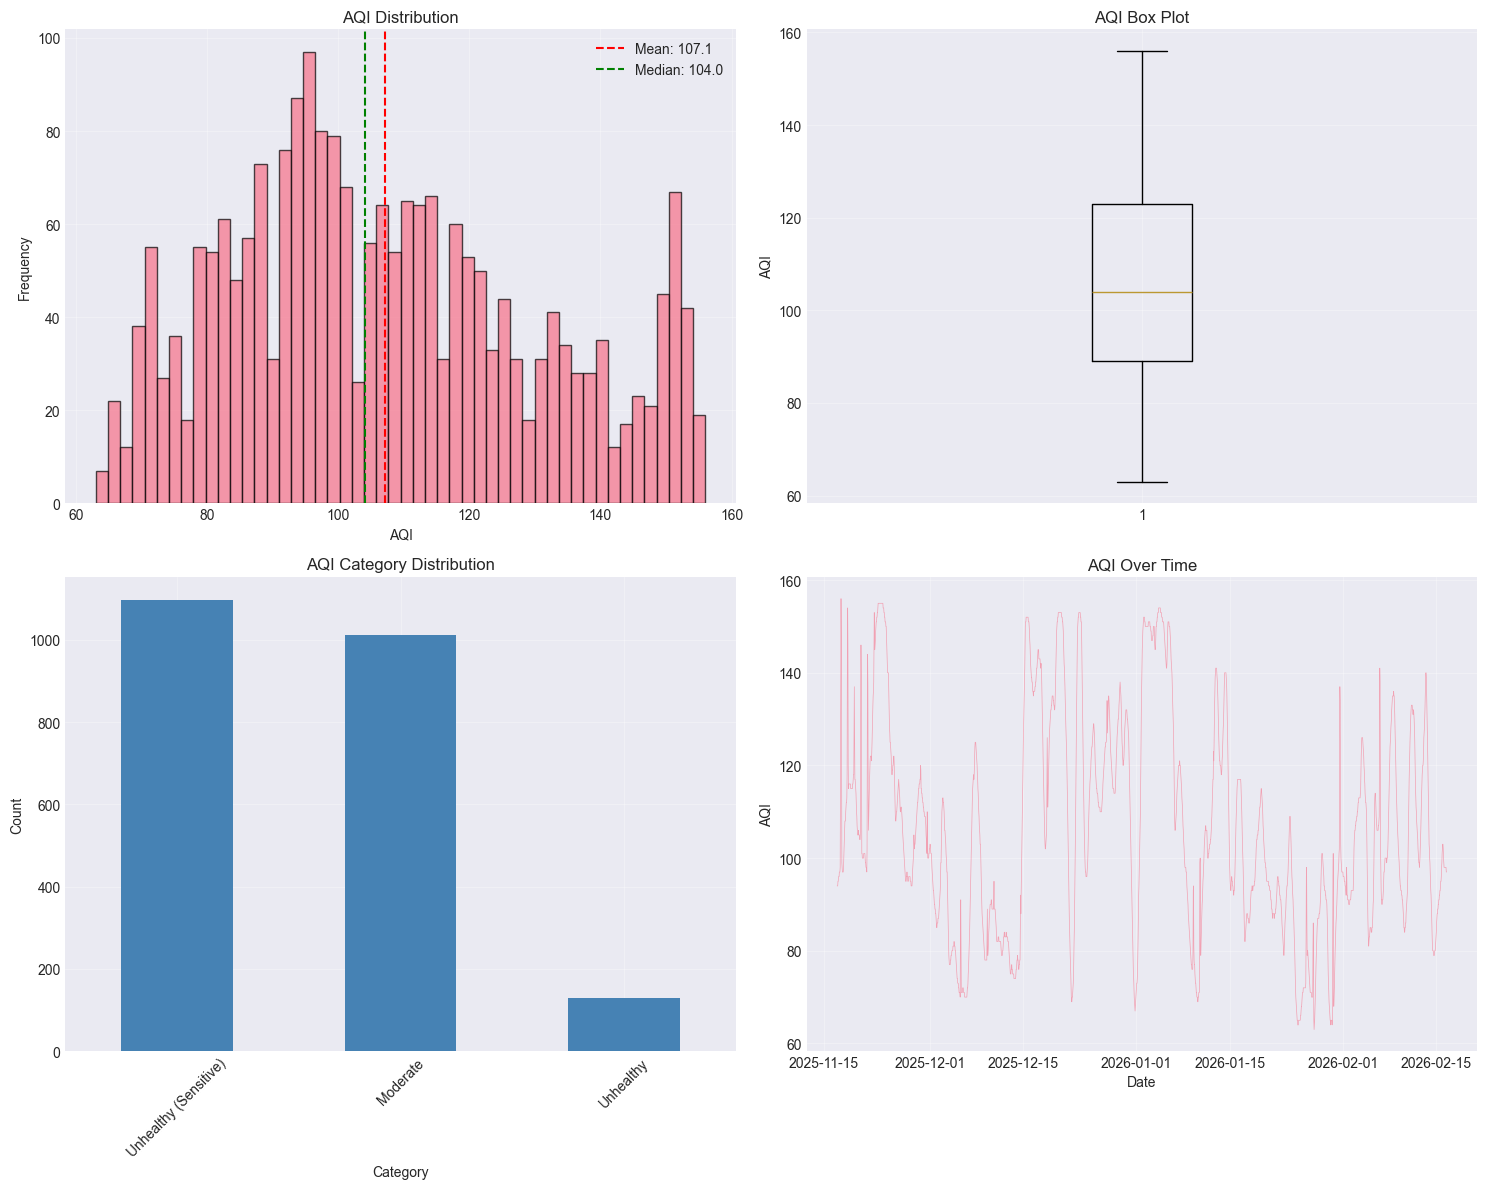

In [12]:
# Visualize AQI distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
axes[0, 0].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['aqi'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["aqi"].mean():.1f}')
axes[0, 0].axvline(df['aqi'].median(), color='green', linestyle='--', 
                   label=f'Median: {df["aqi"].median():.1f}')
axes[0, 0].set_xlabel('AQI')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('AQI Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df['aqi'], vert=True)
axes[0, 1].set_ylabel('AQI')
axes[0, 1].set_title('AQI Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# Category distribution
category_counts.plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('AQI Category Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Time series
axes[1, 1].plot(df['timestamp'], df['aqi'], alpha=0.6, linewidth=0.5)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('AQI')
axes[1, 1].set_title('AQI Over Time')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Pollutant Analysis

In [13]:
pollutants = ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2']

print("📊 Pollutant Statistics:")
df[pollutants].describe()

📊 Pollutant Statistics:


,pm2_5,pm10,no2,o3,co,so2
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000
mean,37.689236,46.999509,33.150201,75.415811,915.841447,22.569406
std,15.021072,21.225195,25.476423,48.431317,535.820057,10.588626
min,8.100000,8.100000,0.000000,0.000000,91.000000,6.600000
25%,26.800000,32.500000,12.000000,32.000000,521.000000,14.800000
50%,35.700000,43.000000,26.700000,70.000000,791.000000,19.700000
75%,45.550000,57.450000,46.800000,115.000000,1175.000000,27.600000
max,95.900000,247.700000,138.500000,195.000000,4515.000000,65.400000


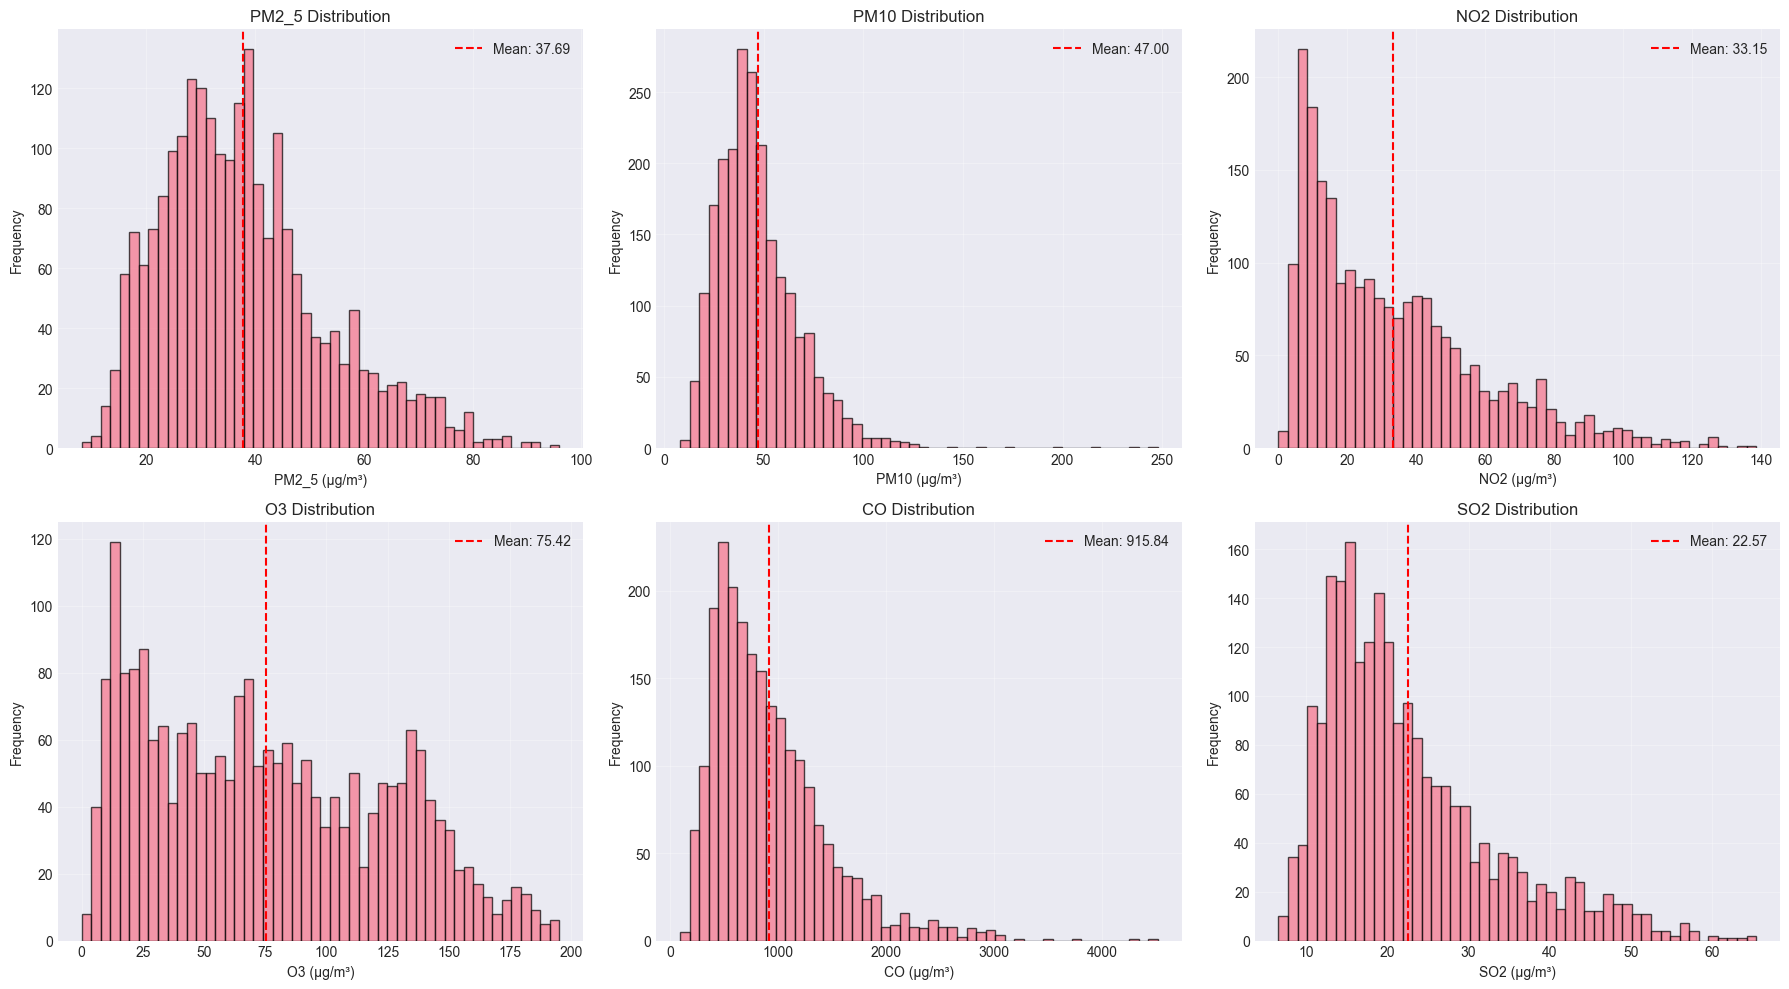

In [14]:
# Visualize pollutant distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, pollutant in enumerate(pollutants):
    axes[idx].hist(df[pollutant].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[pollutant].mean(), color='red', linestyle='--', 
                     label=f'Mean: {df[pollutant].mean():.2f}')
    axes[idx].set_xlabel(f'{pollutant.upper()} (μg/m³)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{pollutant.upper()} Distribution')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

In [15]:
# Correlation matrix
features = pollutants + ['temperature', 'humidity', 'wind_speed', 'aqi']
corr_matrix = df[features].corr()

print("📊 Correlation with AQI:")
aqi_corr = corr_matrix['aqi'].sort_values(ascending=False)
print(aqi_corr)

📊 Correlation with AQI:
aqi            1.000000
pm2_5          0.536224
pm10           0.374872
so2            0.252045
co             0.162979
no2            0.148994
temperature    0.119840
humidity       0.069222
o3             0.028406
wind_speed    -0.114367
Name: aqi, dtype: float64


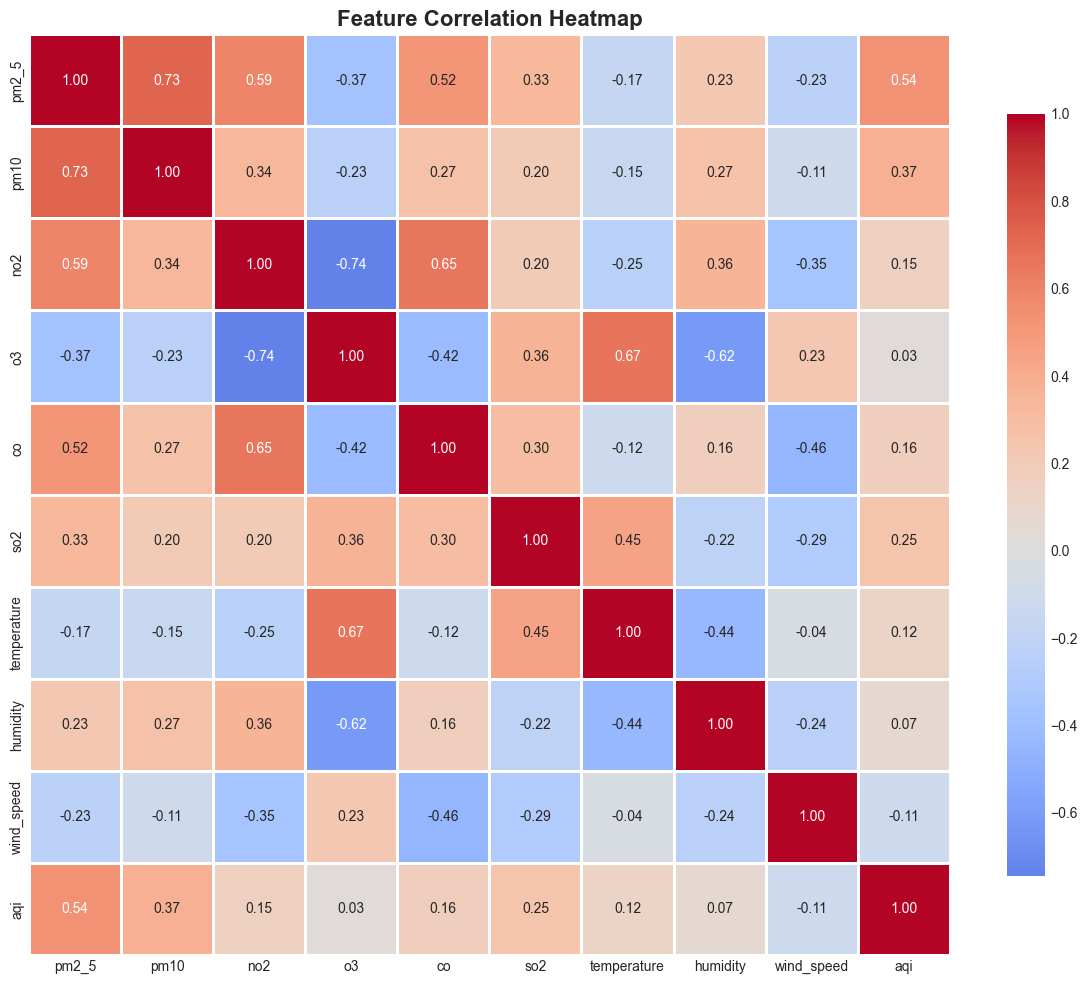

In [16]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Statistical significance
print("📊 Statistical Significance of Correlations with AQI:")
for feature in features[:-1]:
    clean_data = df[[feature, 'aqi']].dropna()
    if len(clean_data) > 0:
        r, p_value = pearsonr(clean_data[feature], clean_data['aqi'])
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"   {feature:15s}: r={r:6.3f}, p-value={p_value:.4e} {significance}")

📊 Statistical Significance of Correlations with AQI:
   pm2_5          : r= 0.536, p-value=6.4977e-167 ***
   pm10           : r= 0.375, p-value=1.2287e-75 ***
   no2            : r= 0.149, p-value=1.3831e-12 ***
   o3             : r= 0.028, p-value=1.7907e-01 
   co             : r= 0.163, p-value=8.5286e-15 ***
   so2            : r= 0.252, p-value=8.7157e-34 ***
   temperature    : r= 0.120, p-value=1.2858e-08 ***
   humidity       : r= 0.069, p-value=1.0470e-03 **
   wind_speed     : r=-0.114, p-value=5.7501e-08 ***


## 6. Temporal Patterns

In [18]:
# Extract temporal features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_name'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month
df['month_name'] = df['timestamp'].dt.month_name()

print("✅ Temporal features extracted")

✅ Temporal features extracted


In [19]:
# Hourly patterns
print("📊 Average AQI by Hour of Day:")
hourly_aqi = df.groupby('hour')['aqi'].agg(['mean', 'std', 'min', 'max'])
hourly_aqi

📊 Average AQI by Hour of Day:


,mean,std,min,max
hour,,,,
0,106.638298,22.997826,68,154
1,106.617021,23.040454,67,153
2,106.542553,23.172873,66,153
3,106.521277,23.332901,65,154
4,106.446809,23.495878,65,155
5,106.425532,23.702679,64,155
6,106.382979,23.861205,64,155
7,106.382979,23.910724,64,155
8,106.340426,23.982320,64,155


In [20]:
# Daily patterns
print("📊 Average AQI by Day of Week:")
daily_aqi = df.groupby('day_name')['aqi'].agg(['mean', 'std', 'count'])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_aqi = daily_aqi.reindex(day_order)
daily_aqi

📊 Average AQI by Day of Week:


,mean,std,count
day_name,,,
Monday,111.298780,24.326570,328
Tuesday,111.833333,23.154961,312
Wednesday,107.673077,19.198963,312
Thursday,98.326923,15.465411,312
Friday,105.619048,24.350503,336
Saturday,105.033639,27.066870,327
Sunday,109.871795,25.710413,312


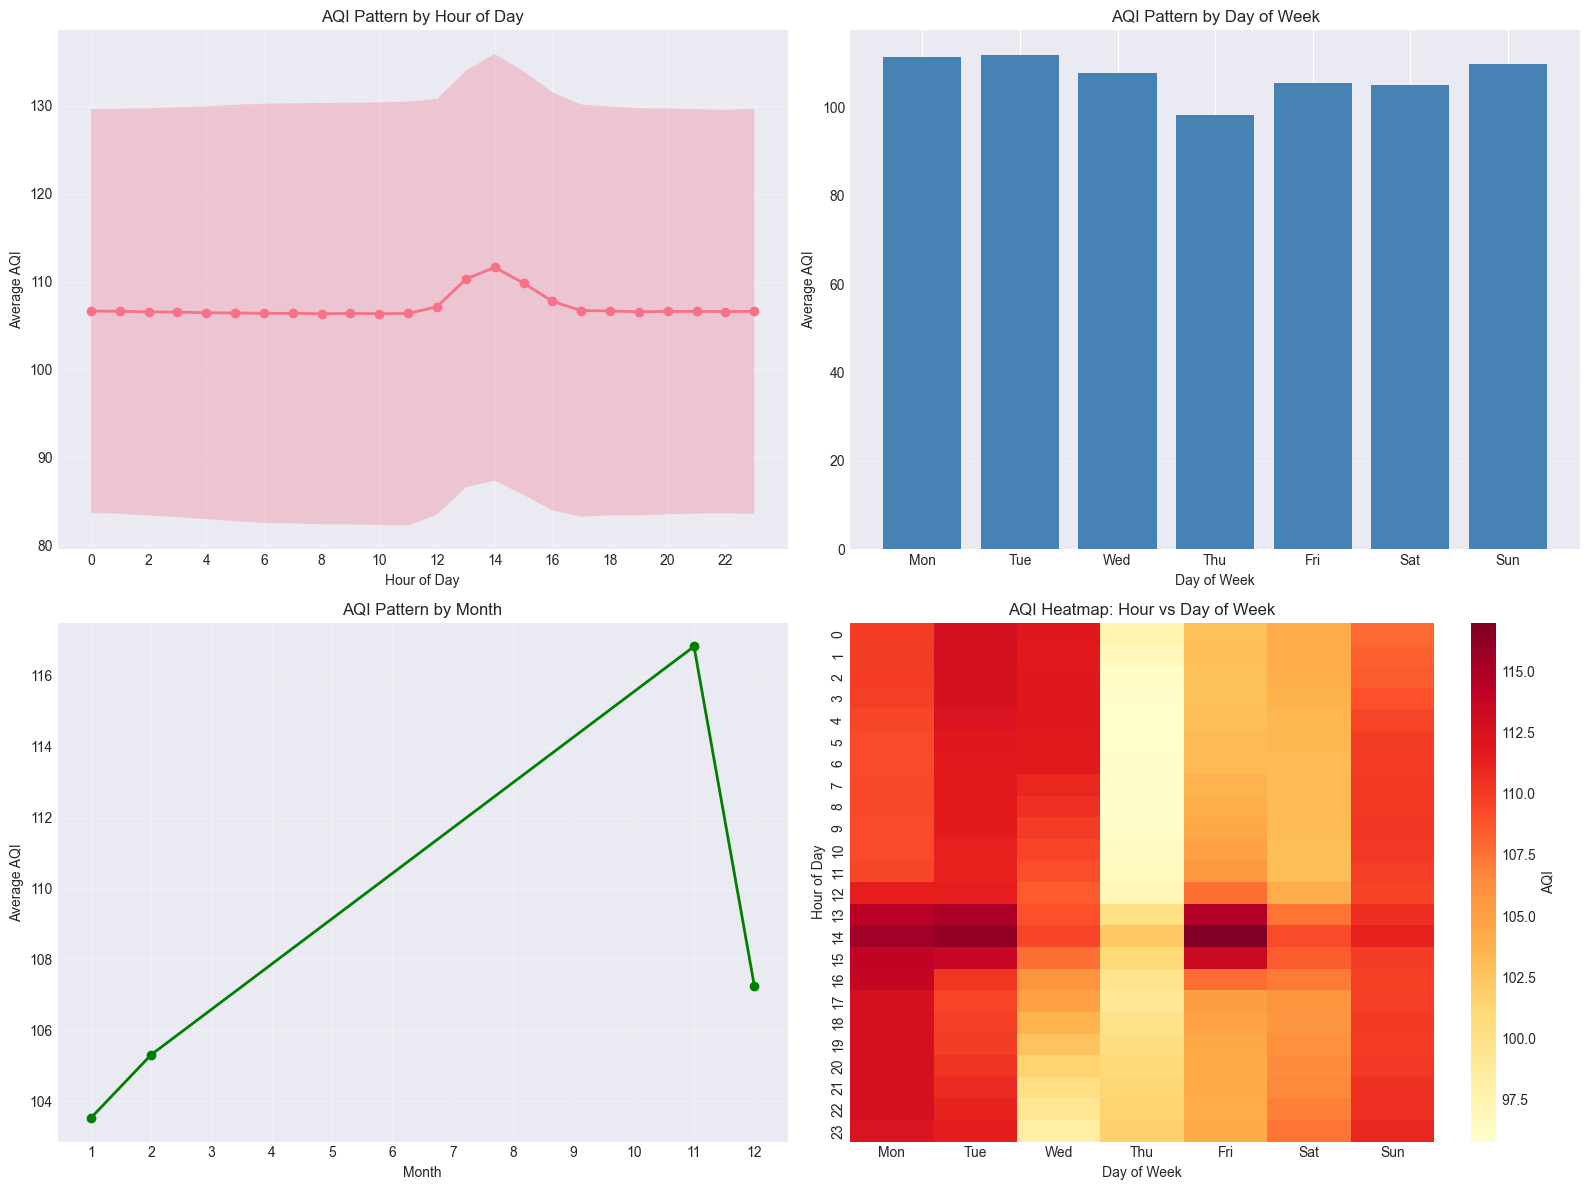

In [21]:
# Temporal visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Hourly pattern
hourly_mean = df.groupby('hour')['aqi'].mean()
hourly_std = df.groupby('hour')['aqi'].std()
axes[0, 0].plot(hourly_mean.index, hourly_mean.values, marker='o', linewidth=2)
axes[0, 0].fill_between(hourly_mean.index, 
                        hourly_mean - hourly_std, 
                        hourly_mean + hourly_std, 
                        alpha=0.3)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average AQI')
axes[0, 0].set_title('AQI Pattern by Hour of Day')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Day of week pattern
daily_mean = df.groupby('day_of_week')['aqi'].mean()
axes[0, 1].bar(range(7), daily_mean.values, color='steelblue')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average AQI')
axes[0, 1].set_title('AQI Pattern by Day of Week')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Monthly pattern
monthly_mean = df.groupby('month')['aqi'].mean()
axes[1, 0].plot(monthly_mean.index, monthly_mean.values, marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average AQI')
axes[1, 0].set_title('AQI Pattern by Month')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(1, 13))

# Heatmap
pivot_table = df.pivot_table(values='aqi', index='hour', columns='day_of_week', aggfunc='mean')
sns.heatmap(pivot_table, annot=False, cmap='YlOrRd', ax=axes[1, 1], cbar_kws={"label": "AQI"})
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Hour of Day')
axes[1, 1].set_title('AQI Heatmap: Hour vs Day of Week')
axes[1, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

## 7. Weather Impact Analysis

In [22]:
weather_features = ['temperature', 'humidity', 'wind_speed']

print("📊 Weather Statistics:")
df[weather_features].describe()

📊 Weather Statistics:


,temperature,humidity,wind_speed
count,2239.000000,2239.000000,2239.000000
mean,20.974185,51.865118,7.964716
std,3.946041,20.431026,3.426455
min,9.200000,12.000000,0.200000
25%,18.100000,36.000000,5.600000
50%,20.800000,50.000000,7.800000
75%,23.900000,66.000000,10.100000
max,29.800000,99.000000,23.800000


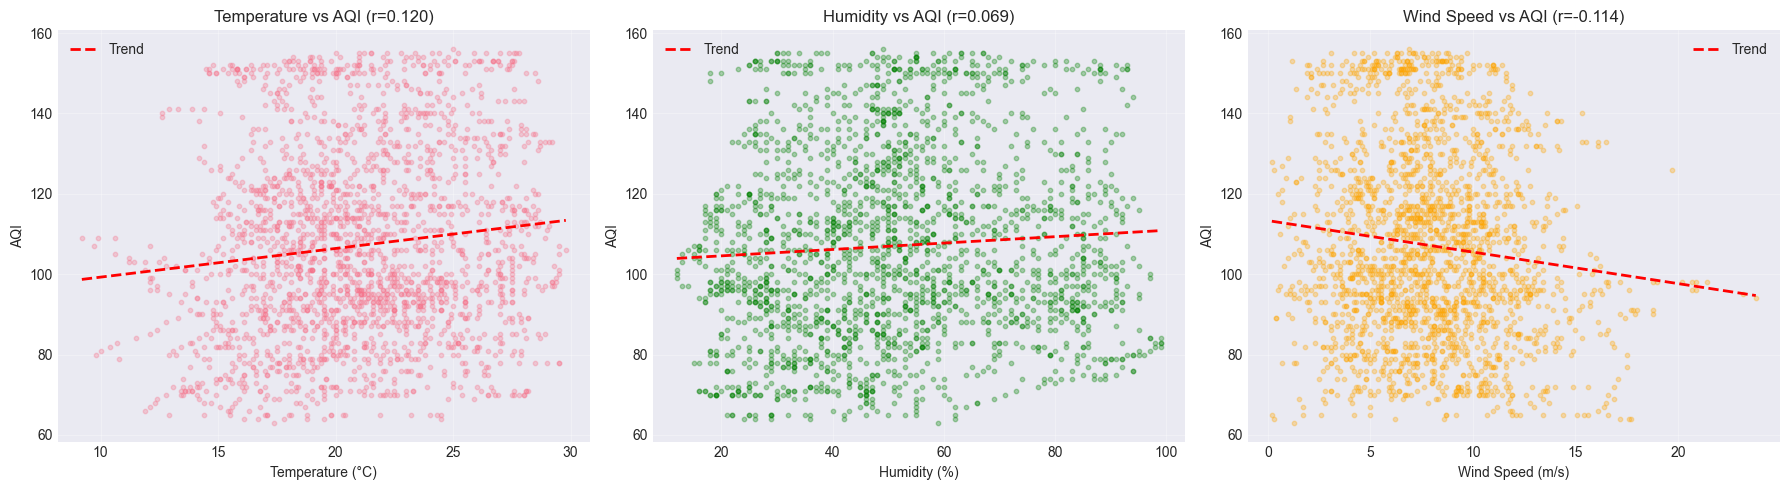

In [23]:
# Weather vs AQI scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temperature vs AQI
axes[0].scatter(df['temperature'], df['aqi'], alpha=0.3, s=10)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('AQI')
axes[0].set_title(f'Temperature vs AQI (r={df[["temperature", "aqi"]].corr().iloc[0,1]:.3f})')
axes[0].grid(True, alpha=0.3)
z = np.polyfit(df['temperature'].dropna(), df.loc[df['temperature'].notna(), 'aqi'], 1)
p = np.poly1d(z)
axes[0].plot(df['temperature'].sort_values(), p(df['temperature'].sort_values()), 
             "r--", linewidth=2, label='Trend')
axes[0].legend()

# Humidity vs AQI
axes[1].scatter(df['humidity'], df['aqi'], alpha=0.3, s=10, color='green')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('AQI')
axes[1].set_title(f'Humidity vs AQI (r={df[["humidity", "aqi"]].corr().iloc[0,1]:.3f})')
axes[1].grid(True, alpha=0.3)
z = np.polyfit(df['humidity'].dropna(), df.loc[df['humidity'].notna(), 'aqi'], 1)
p = np.poly1d(z)
axes[1].plot(df['humidity'].sort_values(), p(df['humidity'].sort_values()), 
             "r--", linewidth=2, label='Trend')
axes[1].legend()

# Wind Speed vs AQI
axes[2].scatter(df['wind_speed'], df['aqi'], alpha=0.3, s=10, color='orange')
axes[2].set_xlabel('Wind Speed (m/s)')
axes[2].set_ylabel('AQI')
axes[2].set_title(f'Wind Speed vs AQI (r={df[["wind_speed", "aqi"]].corr().iloc[0,1]:.3f})')
axes[2].grid(True, alpha=0.3)
z = np.polyfit(df['wind_speed'].dropna(), df.loc[df['wind_speed'].notna(), 'aqi'], 1)
p = np.poly1d(z)
axes[2].plot(df['wind_speed'].sort_values(), p(df['wind_speed'].sort_values()), 
             "r--", linewidth=2, label='Trend')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Lag Features Analysis

In [24]:
lag_features = ['aqi_lag_1', 'aqi_lag_24', 'aqi_change_1h', 'aqi_change_24h']

print("📊 Lag Feature Statistics:")
df[lag_features].describe()

📊 Lag Feature Statistics:


,aqi_lag_1,aqi_lag_24,aqi_change_1h,aqi_change_24h
count,2239.000000,2239.000000,2239.000000,2239.000000
mean,107.109424,107.056722,-0.015185,0.037517
std,23.474210,23.478146,3.052525,24.255610
min,63.000000,63.000000,-26.000000,-69.000000
25%,89.000000,89.000000,-1.000000,-14.000000
50%,104.000000,104.000000,0.000000,-1.000000
75%,123.000000,123.000000,1.000000,15.000000
max,156.000000,156.000000,29.000000,83.000000


In [25]:
# Correlation with target
if 'target_aqi' in df.columns:
    print("📊 Correlation of Lag Features with Target AQI:")
    for feature in lag_features:
        clean_data = df[[feature, 'target_aqi']].dropna()
        if len(clean_data) > 0:
            r, p_value = pearsonr(clean_data[feature], clean_data['target_aqi'])
            print(f"   {feature:20s}: r={r:6.3f}, p-value={p_value:.4e}")

📊 Correlation of Lag Features with Target AQI:
   aqi_lag_1           : r= 0.974, p-value=0.0000e+00
   aqi_lag_24          : r= 0.445, p-value=1.3833e-109
   aqi_change_1h       : r= 0.137, p-value=6.5227e-11
   aqi_change_24h      : r= 0.529, p-value=1.9606e-161


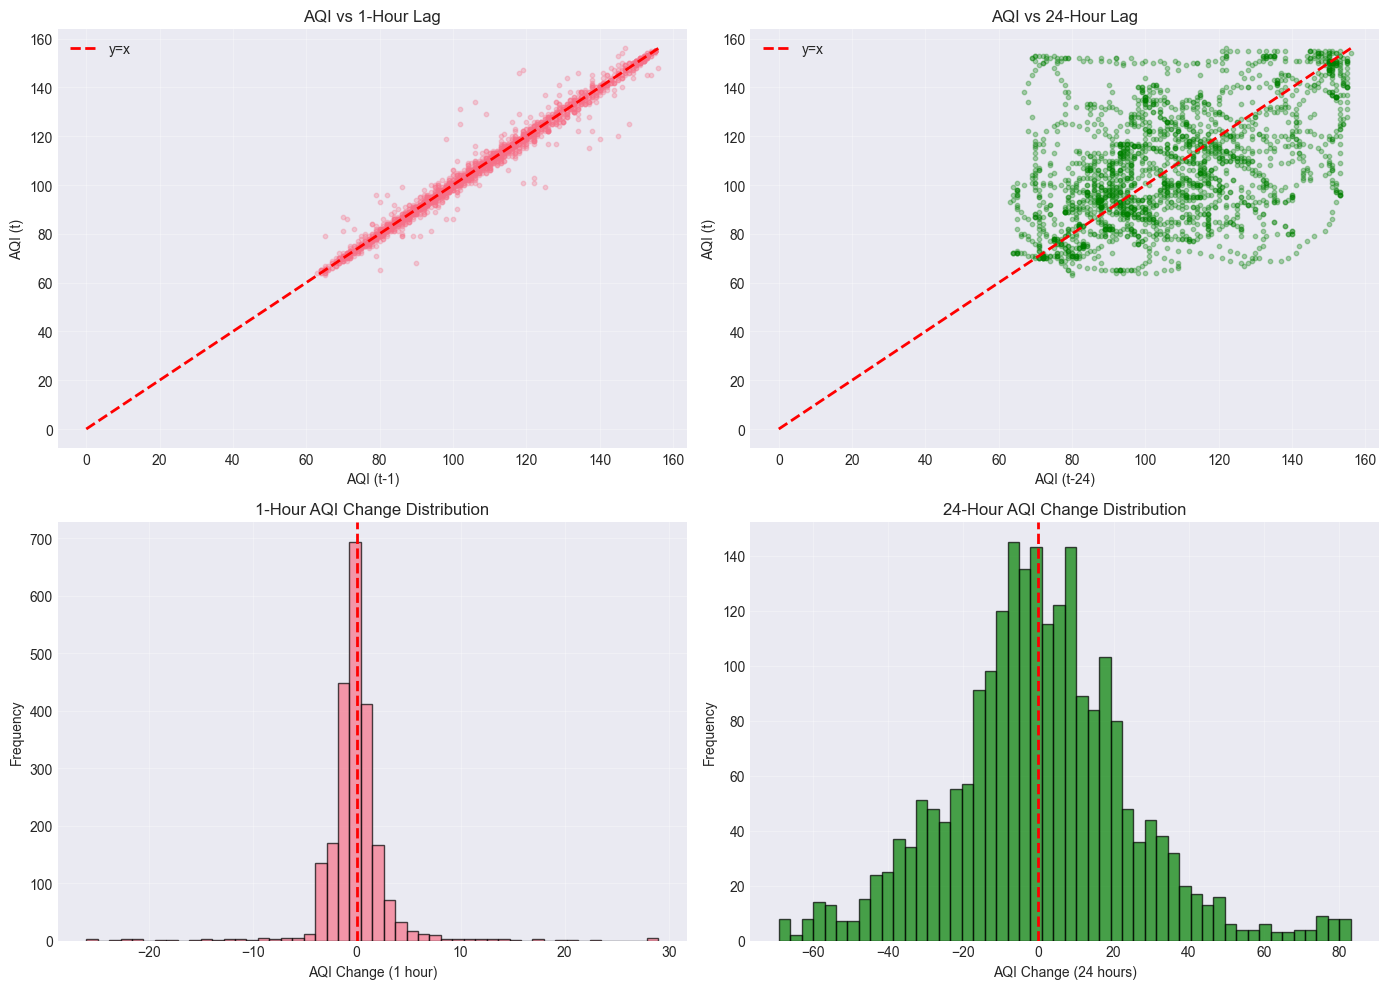

In [26]:
# Visualize lag features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AQI vs 1-hour lag
clean_1h = df[['aqi_lag_1', 'aqi']].dropna()
axes[0, 0].scatter(clean_1h['aqi_lag_1'], clean_1h['aqi'], alpha=0.3, s=10)
axes[0, 0].plot([0, clean_1h['aqi'].max()], [0, clean_1h['aqi'].max()], 
                'r--', linewidth=2, label='y=x')
axes[0, 0].set_xlabel('AQI (t-1)')
axes[0, 0].set_ylabel('AQI (t)')
axes[0, 0].set_title('AQI vs 1-Hour Lag')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AQI vs 24-hour lag
clean_24h = df[['aqi_lag_24', 'aqi']].dropna()
axes[0, 1].scatter(clean_24h['aqi_lag_24'], clean_24h['aqi'], alpha=0.3, s=10, color='green')
axes[0, 1].plot([0, clean_24h['aqi'].max()], [0, clean_24h['aqi'].max()], 
                'r--', linewidth=2, label='y=x')
axes[0, 1].set_xlabel('AQI (t-24)')
axes[0, 1].set_ylabel('AQI (t)')
axes[0, 1].set_title('AQI vs 24-Hour Lag')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 1-hour change
axes[1, 0].hist(df['aqi_change_1h'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('AQI Change (1 hour)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('1-Hour AQI Change Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 24-hour change
axes[1, 1].hist(df['aqi_change_24h'].dropna(), bins=50, edgecolor='black', 
                alpha=0.7, color='green')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('AQI Change (24 hours)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('24-Hour AQI Change Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Outlier Detection

In [27]:
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

all_features = pollutants + weather_features + ['aqi']
outlier_summary = []

for feature in all_features:
    outliers, lower, upper = detect_outliers_iqr(df, feature)
    outlier_pct = (len(outliers) / len(df)) * 100
    outlier_summary.append({
        'Feature': feature,
        'Outliers': len(outliers),
        'Percentage': outlier_pct,
        'Lower Bound': lower,
        'Upper Bound': upper
    })

outlier_df = pd.DataFrame(outlier_summary)
print("📊 Outlier Analysis:")
outlier_df

📊 Outlier Analysis:


,Feature,Outliers,Percentage,Lower Bound,Upper Bound
0,pm2_5,52,2.322465,-1.325,73.675
1,pm10,57,2.545779,-4.925,94.875
2,no2,49,2.188477,-40.200,99.000
3,o3,0,0.000000,-92.500,239.500
4,co,80,3.573024,-460.000,2156.000
5,so2,97,4.332291,-4.400,46.800
6,temperature,1,0.044663,9.400,32.600
7,humidity,0,0.000000,-9.000,111.000
8,wind_speed,30,1.339884,-1.150,16.850
9,aqi,0,0.000000,38.000,174.000


## 10. Feature Importance

In [28]:
# Correlation-based feature importance
if 'target_aqi' in df.columns:
    feature_cols = pollutants + weather_features + ['hour', 'day', 'month', 'day_of_week'] + lag_features
    
    importance = []
    for feature in feature_cols:
        if feature in df.columns:
            clean_data = df[[feature, 'target_aqi']].dropna()
            if len(clean_data) > 0:
                r, _ = pearsonr(clean_data[feature], clean_data['target_aqi'])
                importance.append({
                    'Feature': feature,
                    'Correlation': abs(r),
                    'Direction': 'Positive' if r > 0 else 'Negative'
                })
    
    importance_df = pd.DataFrame(importance).sort_values('Correlation', ascending=False)
    print("📊 Feature Importance (by absolute correlation with target AQI):")
    print(importance_df.to_string(index=False))

📊 Feature Importance (by absolute correlation with target AQI):
       Feature  Correlation Direction
     aqi_lag_1     0.973886  Positive
         pm2_5     0.564970  Positive
aqi_change_24h     0.528642  Positive
    aqi_lag_24     0.445446  Positive
          pm10     0.398207  Positive
           so2     0.280919  Positive
            co     0.166341  Positive
           no2     0.149830  Positive
 aqi_change_1h     0.137450  Positive
   temperature     0.125042  Positive
         month     0.121872  Positive
    wind_speed     0.119189  Negative
      humidity     0.061707  Positive
   day_of_week     0.058681  Negative
            o3     0.042929  Positive
           day     0.008505  Negative
          hour     0.007929  Positive


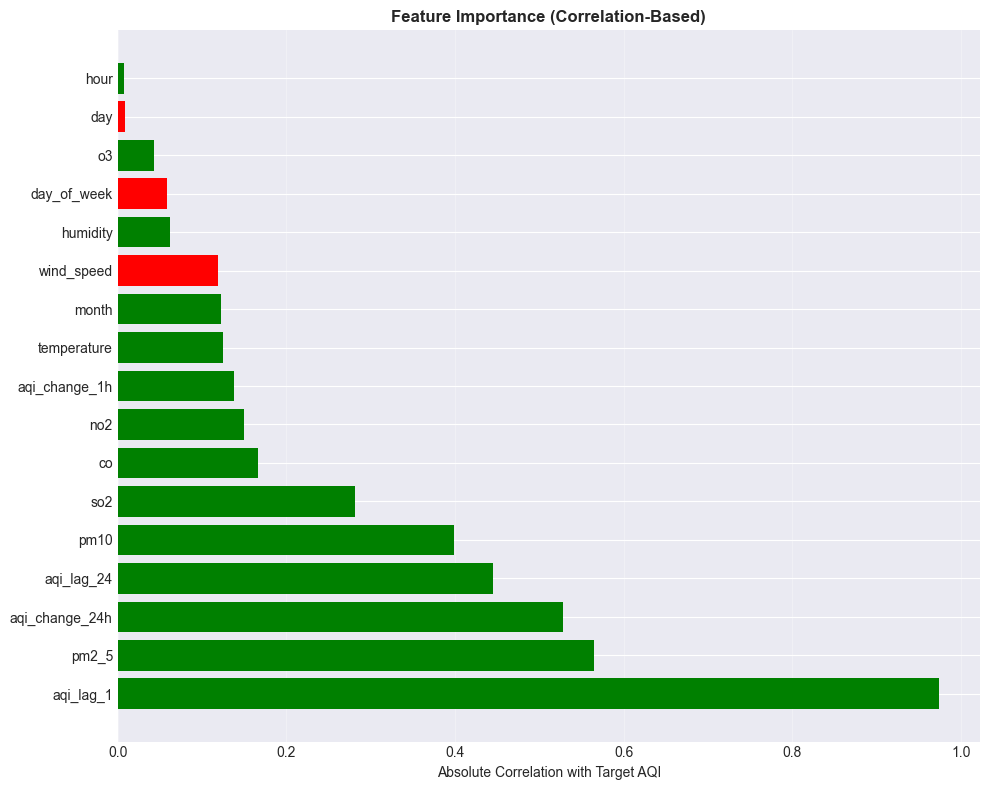

In [29]:
# Visualize feature importance
if 'target_aqi' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['green' if d == 'Positive' else 'red' for d in importance_df['Direction']]
    ax.barh(importance_df['Feature'], importance_df['Correlation'], color=colors)
    ax.set_xlabel('Absolute Correlation with Target AQI')
    ax.set_title('Feature Importance (Correlation-Based)', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

## 11. Data Quality Report

In [30]:
# Completeness
completeness = (df.notna().sum() / len(df)) * 100
completeness_df = pd.DataFrame({
    'Feature': completeness.index,
    'Completeness (%)': completeness.values
}).sort_values('Completeness (%)')

print("📊 Data Completeness:")
completeness_df

📊 Data Completeness:


,Feature,Completeness (%)
0,timestamp,100.0
1,pm2_5,100.0
2,pm10,100.0
3,no2,100.0
4,o3,100.0
5,co,100.0
6,so2,100.0
7,aqi,100.0
8,city,100.0
9,temperature,100.0


In [31]:
# Negative values check
print("📊 Negative Values Check:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"   {col}: {negative_count} negative values")

📊 Negative Values Check:
   aqi_change_1h: 800 negative values
   aqi_change_24h: 1135 negative values


In [32]:
# Zero values check
print("📊 Zero Values Check:")
for col in pollutants + ['aqi']:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"   {col}: {zero_count} zeros ({zero_pct:.2f}%)")

📊 Zero Values Check:
   pm2_5: 0 zeros (0.00%)
   pm10: 0 zeros (0.00%)
   no2: 1 zeros (0.04%)
   o3: 1 zeros (0.04%)
   co: 0 zeros (0.00%)
   so2: 0 zeros (0.00%)
   aqi: 0 zeros (0.00%)


## 12. Key Insights & Summary

In [33]:
print("="*80)
print("KEY INSIGHTS & SUMMARY")
print("="*80)

print("\n🔍 KEY FINDINGS:\n")

print("1. DATA OVERVIEW:")
print(f"   - Total records: {len(df):,}")
print(f"   - Date range: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"   - Average AQI: {df['aqi'].mean():.1f} ({categorize_aqi(df['aqi'].mean())})")

print("\n2. AQI DISTRIBUTION:")
most_common_category = df['aqi_category'].mode()[0]
print(f"   - Most common category: {most_common_category}")
print(f"   - Hazardous days: {(df['aqi'] > 300).sum()} ({(df['aqi'] > 300).sum()/len(df)*100:.1f}%)")
print(f"   - Good air quality days: {(df['aqi'] <= 50).sum()} ({(df['aqi'] <= 50).sum()/len(df)*100:.1f}%)")

print("\n3. TOP CORRELATED FEATURES WITH AQI:")
top_corr = corr_matrix['aqi'].abs().sort_values(ascending=False)[1:6]
for feature, corr_val in top_corr.items():
    print(f"   - {feature}: {corr_val:.3f}")

print("\n4. TEMPORAL PATTERNS:")
hourly_mean = df.groupby('hour')['aqi'].mean()
daily_mean = df.groupby('day_of_week')['aqi'].mean()
peak_hour = hourly_mean.idxmax()
low_hour = hourly_mean.idxmin()
print(f"   - Peak AQI hour: {peak_hour}:00 (avg: {hourly_mean[peak_hour]:.1f})")
print(f"   - Lowest AQI hour: {low_hour}:00 (avg: {hourly_mean[low_hour]:.1f})")

worst_day = daily_mean.idxmax()
best_day = daily_mean.idxmin()
print(f"   - Worst day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][worst_day]}")
print(f"   - Best day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][best_day]}")

print("\n5. WEATHER IMPACT:")
print(f"   - Temperature correlation: {df[['temperature', 'aqi']].corr().iloc[0,1]:.3f}")
print(f"   - Humidity correlation: {df[['humidity', 'aqi']].corr().iloc[0,1]:.3f}")
print(f"   - Wind speed correlation: {df[['wind_speed', 'aqi']].corr().iloc[0,1]:.3f}")

print("\n6. DATA QUALITY:")
overall_completeness = (df.notna().sum().sum() / (len(df) * len(df.columns))) * 100
print(f"   - Overall completeness: {overall_completeness:.2f}%")
print(f"   - Records with missing values: {df.isnull().any(axis=1).sum()}")

print("\n" + "="*80)
print("EDA COMPLETE")
print("="*80)

KEY INSIGHTS & SUMMARY

🔍 KEY FINDINGS:

1. DATA OVERVIEW:
   - Total records: 2,239
   - Date range: 91 days
   - Average AQI: 107.1 (Unhealthy (Sensitive))

2. AQI DISTRIBUTION:
   - Most common category: Unhealthy (Sensitive)
   - Hazardous days: 0 (0.0%)
   - Good air quality days: 0 (0.0%)

3. TOP CORRELATED FEATURES WITH AQI:
   - pm2_5: 0.536
   - pm10: 0.375
   - so2: 0.252
   - co: 0.163
   - no2: 0.149

4. TEMPORAL PATTERNS:
   - Peak AQI hour: 14:00 (avg: 111.6)
   - Lowest AQI hour: 8:00 (avg: 106.3)
   - Worst day: Tue
   - Best day: Thu

5. WEATHER IMPACT:
   - Temperature correlation: 0.120
   - Humidity correlation: 0.069
   - Wind speed correlation: -0.114

6. DATA QUALITY:
   - Overall completeness: 100.00%
   - Records with missing values: 0

EDA COMPLETE
